In [1]:
# ====== Import the required modules
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster, MiniMap
import datetime

In [2]:
# ====== Set pandas options for visibility and verification
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
# ====== Read the fires data from the NIFC API via ArcGis
fire_perimeters = gpd.read_file('https://services3.arcgis.com/T4QMspbfLg3qTGWY/arcgis/rest/services/WFIGS_Interagency_Perimeters_Current/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson')
display(fire_perimeters.head(5))

,OBJECTID,poly_SourceOID,poly_IncidentName,poly_FeatureCategory,poly_MapMethod,poly_GISAcres,poly_DeleteThis,poly_FeatureAccess,poly_FeatureStatus,poly_IsVisible,poly_CreateDate,poly_DateCurrent,poly_PolygonDateTime,poly_IRWINID,poly_FORID,poly_Acres_AutoCalc,poly_SourceGlobalID,poly_Source,attr_SourceOID,attr_ABCDMisc,attr_ADSPermissionState,attr_CalculatedAcres,attr_ContainmentDateTime,attr_ControlDateTime,attr_CreatedBySystem,attr_IncidentSize,attr_DiscoveryAcres,attr_DispatchCenterID,attr_EstimatedCostToDate,attr_FinalAcres,attr_FFReportApprovedByTitle,attr_FFReportApprovedByUnit,attr_FFReportApprovedDate,attr_FireBehaviorGeneral,attr_FireBehaviorGeneral1,attr_FireBehaviorGeneral2,attr_FireBehaviorGeneral3,attr_FireCause,attr_FireCauseGeneral,attr_FireCauseSpecific,attr_FireCode,attr_FireDepartmentID,attr_FireDiscoveryDateTime,attr_FireMgmtComplexity,attr_FireOutDateTime,attr_FireStrategyConfinePercent,attr_FireStrategyFullSuppPrcnt,attr_FireStrategyMonitorPercent,attr_FireStrategyPointZonePrcnt,attr_FSJobCode,attr_FSOverrideCode,attr_GACC,attr_ICS209ReportDateTime,attr_ICS209RptForTimePeriodFrom,attr_ICS209RptForTimePeriodTo,attr_ICS209ReportStatus,attr_IncidentManagementOrg,attr_IncidentName,attr_IncidentShortDescription,attr_IncidentTypeCategory,attr_IncidentTypeKind,attr_InitialLatitude,attr_InitialLongitude,attr_InitialResponseAcres,attr_InitialResponseDateTime,attr_IrwinID,attr_IsFireCauseInvestigated,attr_IsFireCodeRequested,attr_IsFSAssisted,attr_IsMultiJurisdictional,attr_IsReimbursable,attr_IsTrespass,attr_IsUnifiedCommand,attr_LocalIncidentIdentifier,attr_ModifiedBySystem,attr_PercentContained,attr_PercentPerimToBeContained,attr_POOCity,attr_POOCounty,attr_POODispatchCenterID,attr_POOFips,attr_POOJurisdictionalAgency,attr_POOJurisdictionalUnit,attr_POOJurisdictUnitParentUnit,attr_POOLandownerCategory,attr_POOLandownerKind,attr_POOLegalDescPrincipalMerid,attr_POOLegalDescQtr,attr_POOLegalDescQtrQtr,attr_POOLegalDescRange,attr_POOLegalDescSection,attr_POOLegalDescTownship,attr_POOPredictiveServiceAreaID,attr_POOProtectingAgency,attr_POOProtectingUnit,attr_POOState,attr_PredominantFuelGroup,attr_PredominantFuelModel,attr_PrimaryFuelModel,attr_SecondaryFuelModel,attr_TotalIncidentPersonnel,attr_UniqueFireIdentifier,attr_FORID,attr_WFDSSDecisionStatus,attr_EstimatedFinalCost,attr_OrganizationalAssessment,attr_StratDecisionPublishDate,attr_CreatedOnDateTime_dt,attr_ModifiedOnDateTime_dt,attr_Source,attr_ActiveFireCandidate,attr_IsCpxChild,attr_CpxName,attr_CpxID,attr_SourceGlobalID,GlobalID,Shape__Area,Shape__Length,attr_IncidentComplexityLevel,geometry
0,37190,2217,Lebar,Wildfire Daily Fire Perimeter,Mixed Methods,NaN,No,Public,Approved,Yes,1740422477000,1740759310000,NaN,{DB5C769E-79D3-48CB-B9DD-80E56E3063EE},None,512.723102,{F21880FE-EACC-48C9-9909-087C84CACB68},2025 NIFS,33055974,None,DEFAULT,NaN,None,None,wildcade,512.00,30.0,WYCPC,2000.0,None,None,None,None,Active,None,Wind Driven Runs,Running,Human,None,None,SFV7,None,1740335400000,None,None,0.0,100.0,0.0,0.0,None,None,RMCC,1.740434e+12,1.740341e+12,1.740424e+12,F,Type 4 IC,Lebar,10 miles north of Douglas,WF,FI,42.919821,-105.267220,None,NaN,{DB5C769E-79D3-48CB-B9DD-80E56E3063EE},NaN,0,1.0,None,None,None,0.0,250017,ics209,100.0,100.0,Douglas,Converse,WYCPC,56009,None,None,None,Private,Private,None,None,None,None,None,None,RM04,C&L,WYCOX,US-WY,None,None,Short Grass (1 foot),Tall Grass (2.5 feet),32.0,2025-WYCOX-250017,None,No Decision,NaN,None,NaN,1740365174000,1740433893000,IRWIN,1,0,None,None,{F0353CBC-81CE-4657-819B-7A8CE3AFA40E},741e8949-172d-463f-98d7-83670de6d935,0.000229,0.152801,None,"POLYGON ((-105.26445 42.89318, -105.26457 42.8..."
1,37161,2428,White face,Wildfire Daily Fire Perimeter,Mixed Methods,43.500000,No,Public,Approved,Yes,1740602967000,1740604817000,1.740603e+12,{9B77A8AE-60DC-436B-9FD3-58F259348034},None,43.462441,{B095F25C-D728-4AFA-B5A7-CCA5416669CA},2025 NIFS,33056261,None,DEFAULT,43.44,None,None,INFORM_Inspector,43.44,0.1,SDGPC,NaN,None,

In [4]:
# ====== Convert the Linux time/date values
d1 = []
d2 = []
d3 = []
for idx, row in fire_perimeters.iterrows():
    d1_date = datetime.datetime.fromtimestamp(row['attr_CreatedOnDateTime_dt'] / 1000)
    d1_str = d1_date.strftime('%Y-%m-%d %H:%M:%S')
    d1.append(d1_str)
    d2_date = datetime.datetime.fromtimestamp(row['attr_ModifiedOnDateTime_dt'] / 1000)
    d2_str = d2_date.strftime('%Y-%m-%d %H:%M:%S')
    d2.append(d2_str)
    d3_date = datetime.datetime.fromtimestamp(row['attr_FireDiscoveryDateTime'] / 1000)
    d3_str = d3_date.strftime('%Y-%m-%d %H:%M:%S')
    d3.append(d3_str)
    
fire_perimeters['CreatedOnDateTime'] = d1
fire_perimeters['ModifiedOnDateTime'] = d2
fire_perimeters['FireDiscoveryDateTime'] = d3

In [5]:
# ====== Reduce the data and relate any incidents to one another
fire_perimeters.sort_values(by='poly_Acres_AutoCalc', ascending=False, inplace=True)
fires = fire_perimeters[['poly_IncidentName','poly_FeatureCategory','poly_GISAcres','poly_IRWINID','poly_Acres_AutoCalc','attr_EstimatedCostToDate',
                 'attr_DiscoveryAcres','poly_Source','attr_FireCause','attr_FireCauseGeneral','FireDiscoveryDateTime',
                 'attr_IncidentTypeCategory','attr_IncidentManagementOrg','attr_InitialLatitude','attr_InitialLongitude','attr_POOCity',
                 'attr_POOCounty','attr_POOState','CreatedOnDateTime','ModifiedOnDateTime','geometry']]

display(fires.head(5))

,poly_IncidentName,poly_FeatureCategory,poly_GISAcres,poly_IRWINID,poly_Acres_AutoCalc,attr_EstimatedCostToDate,attr_DiscoveryAcres,poly_Source,attr_FireCause,attr_FireCauseGeneral,FireDiscoveryDateTime,attr_IncidentTypeCategory,attr_IncidentManagementOrg,attr_InitialLatitude,attr_InitialLongitude,attr_POOCity,attr_POOCounty,attr_POOState,CreatedOnDateTime,ModifiedOnDateTime,geometry
13,Covington Drive,Wildfire Daily Fire Perimeter,2127.941293,{17400B93-8F32-48E1-B16F-782B002EAE57},2127.933811,NaN,0.1,2025 NIFS,Undetermined,None,2025-03-02 09:12:07,WF,None,33.804617,-78.859600,None,Horry,US-SC,2025-03-02 09:16:33,2025-03-02 09:19:01,"POLYGON ((-78.93298 33.78209, -78.93266 33.782..."
4,Devils Horn 1-3 RX,Prescribed Fire,1581.000000,{B1B3A08E-3A53-452C-9B8E-6A4BC401652F},1571.445713,NaN,1581.0,2025 NIFS,Undetermined,None,2025-02-27 10:00:15,RX,None,36.842220,-91.083183,None,Carter,US-MO,2025-02-27 10:12:57,2025-03-02 10:33:49,"POLYGON ((-91.0973 36.81632, -91.09745 36.8163..."
2,Two Barrel,Wildfire Daily Fire Perimeter,1159.939875,{0E4350FA-651A-4E0D-97A2-D99D481CE2F6},1159.935797,200000.0,15.0,2025 NIFS,Undetermined,None,2025-02-26 11:50:00,WF,Type 4 IC,30.179200,-84.996300,None,Liberty,US-FL,2025-02-26 11:55:50,2025-03-03 18:33:46,"POLYGON ((-85.00731 30.1732, -85.00731 30.1732..."
12,Cotham 1 and 2 RX,Prescribed Fire,1084.000000,{58B00052-2FDB-47AC-B2C8-CA9AA393F6B6},1082.277966,NaN,1084.0,2025 NIFS,Undetermined,None,2025-03-02 08:17:37,RX,None,36.848582,-91.182146,None,Carter,US-MO,2025-03-02 10:29:45,2025-03-02 11:27:19,"POLYGON ((-91.1675 36.84711, -91.16755 36.8470..."
10,3910,Wildfire Daily Fire Perimeter,593.879912,{34A6C160-F478-42AE-BECE-225961DF5E3F},593.877806,150000.0,NaN,2025 NIFS,Human,None,2025-03-02 00:25:00,WF,Type 3 IC,NaN,NaN,Tryon,Polk,US-NC,2025-03-01 14:30:54,2025-03-03 16:07:14,"POLYGON ((-82.30911 35.22592, -82.30891 35.225..."


In [6]:
# ====== Create a base map centered on the US 
def get_color(gis_acres):
    if pd.isna(gis_acres):
        return '#808080'  # Gray for missing values
    # Normalize acres to a 0-1 scale (using log scale due to potential large range)
    min_acres = fires['poly_Acres_AutoCalc'].min()
    max_acres = fires['poly_Acres_AutoCalc'].max()
    if min_acres == max_acres:  # Avoid division by zero
        norm_value = 0.5
    else:
        norm_value = (np.log1p(gis_acres) - np.log1p(min_acres)) / (np.log1p(max_acres) - np.log1p(min_acres))
    # Interpolate between red (small) and blue (large)
    r = int(255 * (1 - norm_value))  # Red decreases as size increases
    b = int(255 * norm_value)        # Blue increases as size increases
    return f'#{r:02x}00{b:02x}'     # Format as hex color (no green component)

# ====== Create the map
m = folium.Map(location=[39.8283, -98.5795], zoom_start=4, tiles='OpenStreetMap')

# ====== Create feature group for perimeters
perimeters_group = folium.FeatureGroup(name='Fire Perimeters')
start_locations_group = folium.FeatureGroup(name='Fire Start Location')

# ====== Add fire perimeters with color scale
for idx, row in fires.iterrows():
    geo_json = row['geometry'].__geo_interface__
    
    # Create popup with all fields
    popup_info = "<br>".join([f"{col}: {row.get(col, 'N/A')}" for col in fires.columns if col != 'geometry'])
    
    # Get color based on poly_GISAcres
    color = get_color(row['poly_Acres_AutoCalc'])
    
    folium.GeoJson(
        geo_json,
        style_function=lambda x, color=color: {  # Pass color to lambda
            'fillColor': color,
            'color': color,
            'weight': 1,
            'fillOpacity': 0.5
        },
        tooltip=row.get('poly_IncidentName', 'Unknown Fire'),
        popup=folium.Popup(popup_info, max_width=400)
    ).add_to(perimeters_group)

# Add fire start locations with red fire icons
for idx, row in fires.iterrows():
    lat = row.get('attr_InitialLatitude')
    lon = row.get('attr_InitialLongitude')
    
    # Check for valid, non-NaN coordinates
    if (lat is not None and lon is not None and 
        not np.isnan(lat) and not np.isnan(lon)):
        popup_info = "<br>".join([f"{col}: {row.get(col, 'N/A')}" for col in fires.columns if col != 'geometry'])
        
        folium.Marker(
            location=[lat, lon],
            icon=folium.Icon(
                icon='fire',
                prefix='fa',
                color='red'
            ),
            tooltip=row.get('poly_IncidentName', 'Unknown Fire'),
            popup=folium.Popup(popup_info, max_width=400)
        ).add_to(start_locations_group)

# Add feature groups to the map
perimeters_group.add_to(m)
start_locations_group.add_to(m)

# ====== Add the feature group to the map
perimeters_group.add_to(m)

# ====== Add layer control
folium.LayerControl().add_to(m)

# ====== Add minimap
minimap = MiniMap()
m.add_child(minimap)

In [7]:
# ====== Save the map as an HTML
m.save('wildfire_map.html')

In [8]:
import os
print(os.listdir())

['requirements.txt', 'nifc_fires_map.ipynb', 'README.md', 'wildfire_map.png', '.ipynb_checkpoints', 'venv', '.git', 'wildfire_map.html', '.idea']


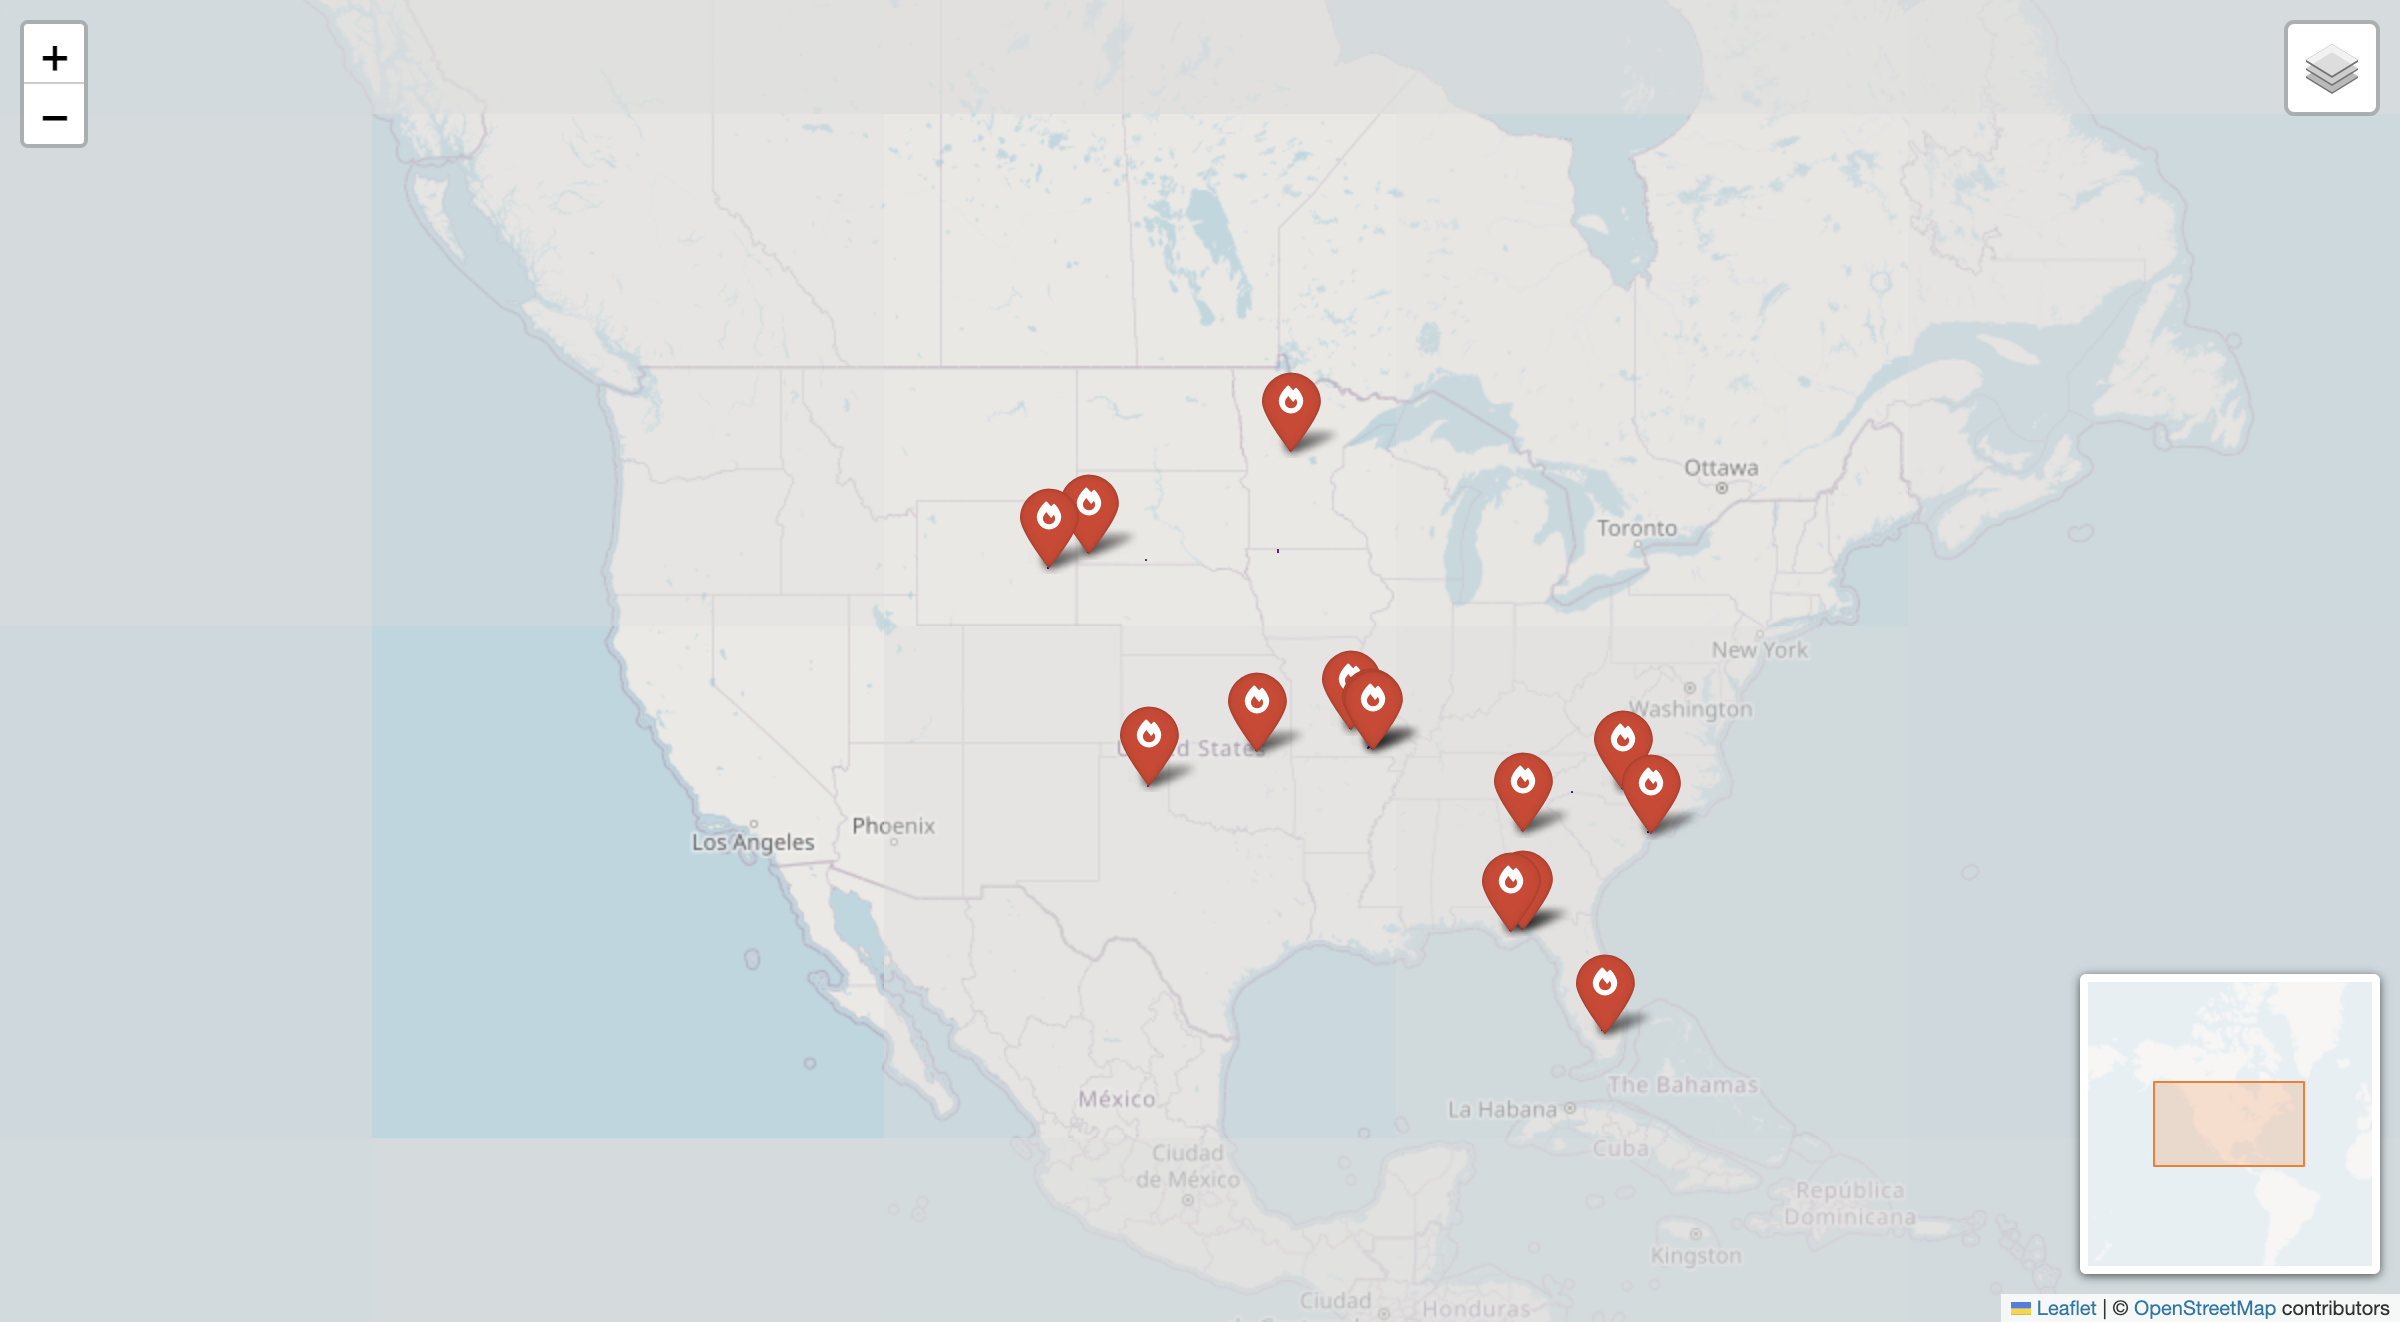

In [9]:
from selenium import webdriver
from io import BytesIO
from IPython.display import Image 

# ====== Use Selenium to take a screenshot
options = webdriver.ChromeOptions()
options.add_argument('--headless')  # Run without opening a browser window
driver = webdriver.Chrome(options=options)
driver.set_window_size(1200, 800)  # Set desired image size
driver.get('file:///Users/daviddemand/PycharmProjects/nfic_api/wildfire_map.html')  # Use full local path
img_data = driver.get_screenshot_as_png()
driver.quit()

# Save the image
with open('wildfire_map.png', 'wb') as f:
    f.write(img_data)

# Display the image in the notebook
display(Image(img_data))

In [10]:
# ====== Add markdown for GitHub viewers
print("For GitHub viewers: View the interactive map at: https://raw.githubusercontent.com/ddemand/nfic_api/dev/wildfire_perimeters_map.html")

For GitHub viewers: View the interactive map at: https://raw.githubusercontent.com/ddemand/nfic_api/dev/wildfire_perimeters_map.html
